# **Project:** Air Quality Forecasting using Machine Learning


# **Goal:**  To Predict short-term and medium-term pollutant levels (e.g., PM2.5) using sensor and weather data, enabling proactive health & policy actions.

# **Objectives:**
- Build forecasting models (baseline → advanced ML/DL)
- Create a full pipeline: data ingestion → preprocessing → modeling → evaluation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#IMPORT LIBRARIES

import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [ ]:
# READING DATASETS

station_hour = pd.read_excel('/content/drive/MyDrive/FSP PROJECT/station-hour.xlsx')
station = pd.read_excel('/content/drive/MyDrive/FSP PROJECT/station.xlsx')

In [ ]:
station_hour.head()

,StationId,Date,Time,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-25,09:00:00,104.00,148.50,1.93,23.00,13.75,9.80,0.1,15.30,117.62,0.30,10.40,0.23,155,Moderate
1,AP001,2017-11-25,10:00:00,94.50,142.00,1.33,16.25,9.75,9.65,0.1,17.00,136.23,0.28,7.10,0.15,159,Moderate
2,AP001,2017-11-25,11:00:00,82.75,126.50,1.47,14.83,9.07,9.70,0.1,15.40,149.92,0.20,4.55,0.08,173,Moderate
3,AP001,2017-11-25,14:00:00,68.50,117.00,1.35,13.60,8.35,7.40,0.1,21.80,161.70,0.10,2.30,0.00,191,Moderate
4,AP001,2017-11-25,15:00:00,69.25,112.25,1.52,11.80,7.55,9.25,0.1,21.38,161.68,0.10,2.35,0.00,191,Moderate


In [ ]:
station.head()

,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP005,"GVM Corporation, Visakhapatnam - APPCB",Visakhapatnam,Andhra Pradesh,Active
2,AS001,"Railway Colony, Guwahati - APCB",Guwahati,Assam,Active
3,BR005,"DRM Office Danapur, Patna - BSPCB",Patna,Bihar,Active
4,BR006,"Govt. High School Shikarpur, Patna - BSPCB",Patna,Bihar,Active


In [ ]:
station_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219037 entries, 0 to 219036
Data columns (total 17 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   StationId   219037 non-null  object        
 1   Date        219037 non-null  datetime64[ns]
 2   Time        219037 non-null  object        
 3   PM2.5       211535 non-null  float64       
 4   PM10        214232 non-null  float64       
 5   NO          219037 non-null  float64       
 6   NO2         217683 non-null  float64       
 7   NOx         217839 non-null  float64       
 8   NH3         219037 non-null  float64       
 9   CO          216699 non-null  float64       
 10  SO2         219037 non-null  float64       
 11  O3          219037 non-null  float64       
 12  Benzene     219037 non-null  float64       
 13  Toluene     218942 non-null  float64       
 14  Xylene      219037 non-null  float64       
 15  AQI         219037 non-null  int64         
 16  AQ

In [ ]:
station_hour['AQI_Bucket'].value_counts()

,count
AQI_Bucket,
Moderate,93653
Satisfactory,75287
Good,25788
Poor,12547
Very Poor,9685
Severe,2077


In [ ]:
station_hour.isnull().sum()

,0
StationId,0
Date,0
Time,0
PM2.5,7502
PM10,4805
NO,0
NO2,1354
NOx,1198
NH3,0
CO,2338


** Since the data is highly skewed, we will replace the null values with median values of the particular column.**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#REPLACING THE MISSING VALUES WITH THE MEDIAN VALUES OF THE RESOECTIVE COLUMNS

station_hour['PM2.5'].fillna(station_hour['PM2.5'].median(), inplace=True)
station_hour['PM10'].fillna(station_hour['PM10'].median(), inplace=True)

In [ ]:
station_hour.isnull().sum()

,0
StationId,0
Date,0
Time,0
PM2.5,0
PM10,0
NO,0
NO2,1354
NOx,1198
NH3,0
CO,2338


In [ ]:
#REPLACING THE MISSING VALUES WITH THE MEDIAN VALUES OF THE RESOECTIVE COLUMNS

station_hour['NO2'].fillna(station_hour['NO2'].median(), inplace=True)
station_hour['NOx'].fillna(station_hour['NOx'].median(), inplace=True)
station_hour['CO'].fillna(station_hour['CO'].median(), inplace=True)
station_hour['Toluene'].fillna(station_hour['Toluene'].median(), inplace=True)

In [ ]:
station_hour.isnull().sum()

,0
StationId,0
Date,0
Time,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0


**station_hour datasets has many zero values which are just null values, so we convert it to null values.**

In [ ]:
station_hour.replace(0.0, np.nan, inplace=True)

In [ ]:
station_hour[station_hour['NOx'] == 0]

,StationId,Date,Time,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket


In [ ]:
station_hour[station_hour['CO'] == 0]

,StationId,Date,Time,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket


In [ ]:
station_hour[station_hour==0]

,StationId,Date,Time,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219032,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
219033,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
219034,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
219035,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
station_hour.isnull().sum()

,0
StationId,0
Date,0
Time,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,981
NH3,0
CO,10794


**Replacing the changed null values to median values of the column.**

In [ ]:
station_hour['Benzene'].fillna(station_hour['Benzene'].median(), inplace=True)
station_hour['NOx'].fillna(station_hour['NOx'].median(), inplace=True)
station_hour['CO'].fillna(station_hour['CO'].median(), inplace=True)
station_hour['Toluene'].fillna(station_hour['Toluene'].median(), inplace=True)

In [ ]:
station_hour.isnull().sum()

,0
StationId,0
Date,0
Time,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0


**Since XYLENE column has more than 25% null values, we are dropping it.**

In [ ]:
station_hour.drop(columns=['Xylene'], inplace=True)

In [ ]:
station_hour.columns

Index(['StationId', 'Date', 'Time', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
       'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI', 'AQI_Bucket'],
      dtype='object')

**Changing the TIME column to DateTime type**

In [ ]:
station_hour['Time'] = pd.to_datetime(station_hour['Time'], format='%H:%M:%S')

In [ ]:
station_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219037 entries, 0 to 219036
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   StationId   219037 non-null  object        
 1   Date        219037 non-null  datetime64[ns]
 2   Time        219037 non-null  datetime64[ns]
 3   PM2.5       219037 non-null  float64       
 4   PM10        219037 non-null  float64       
 5   NO          219037 non-null  float64       
 6   NO2         219037 non-null  float64       
 7   NOx         219037 non-null  float64       
 8   NH3         219037 non-null  float64       
 9   CO          219037 non-null  float64       
 10  SO2         219037 non-null  float64       
 11  O3          219037 non-null  float64       
 12  Benzene     219037 non-null  float64       
 13  Toluene     219037 non-null  float64       
 14  AQI         219037 non-null  int64         
 15  AQI_Bucket  219037 non-null  object        
dtypes:

**Merging the two datasets based on StationId column.**

In [ ]:
merged_df = pd.merge(station_hour, station, on='StationId', how='inner')  # Only matching IDs

In [ ]:
merged_df

,StationId,Date,Time,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket,StationName,City,State,Status
0,AP001,2017-11-25,1900-01-01 09:00:00,104.00,148.50,1.93,23.00,13.75,9.80,0.10,15.30,117.62,0.30,10.40,155,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP001,2017-11-25,1900-01-01 10:00:00,94.50,142.00,1.33,16.25,9.75,9.65,0.10,17.00,136.23,0.28,7.10,159,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
2,AP001,2017-11-25,1900-01-01 11:00:00,82.75,126.50,1.47,14.83,9.07,9.70,0.10,15.40,149.92,0.20,4.55,173,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
3,AP001,2017-11-25,1900-01-01 14:00:00,68.50,117.00,1.35,13.60,8.35,7.40,0.10,21.80,161.70,0.10,2.30,191,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
4,AP001,2017-11-25,1900-01-01 15:00:00,69.25,112.25,1.52,11.80,7.55,9.25,0.10,21.38,161.68,0.10,2.35,191,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219032,WB010,2020-02-14,1900-01-01 11:00:00,85.50,161.35,16.15,65.22,81.32,39.08,0.79,8.60,20.47,57.14,51.31,222,Poor,"Jadavpur, Kolkata - WBPCB",Kolkata,West Bengal,Active
219033,WB010,2020-02-14,1900-01-01 12:00:00,73.75,143.65,8.40,52.65,61.08,38.53,0.66,9.82,26.58,53.71,51.38,219,Poor,"Jadavpur, Kolkata - WBPCB",Kolkata,West Bengal,Active
219034,WB010,2020-02-14,1900-01-01 13:00:00,71.50,133.38,5.60,45.03,50.62,42.62,0.55,9.57,28.28,56.80,56.27,217,Poor,"Jadavpur, Kolkata - WBPCB",Kolkata,West Bengal,Active
219035,WB010,2020-02-14,1900-01-01 14:00:00,54.47,117.12,4.20,39.00,43.17,48.02,0.62,9.20,31.63,56.04,55.58,215,Poor,"Jadavpur, Kolkata - WBPCB",Kolkata,West Bengal,Active


In [ ]:
merged_df.isnull().sum()

,0
StationId,0
Date,0
Time,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0


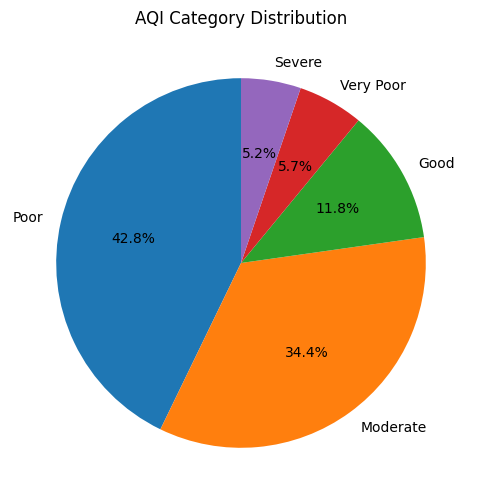

In [ ]:
import pandas as pd

aqi_values = merged_df['AQI']

bins = [0, 50, 100, 200, 300,500]
labels = ['Good', 'Moderate', 'Poor', 'Very Poor', 'Severe']
merged_df['AQI_Category'] = pd.cut(aqi_values, bins=bins, labels=labels)

category_counts = merged_df['AQI_Category'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("AQI Category Distribution")
plt.show()


**Feature Engineering**

In [ ]:
def create_features(df, target_cols, date_col="Date", time_col="Time"):
    df = merged_df.copy()

    # Combine Date + Time
    df['datetime'] = df[date_col] + pd.to_timedelta(df[time_col].dt.strftime('%H:%M:%S'))
    df = df.sort_values('datetime')

    # Keep other pollutant columns as they are
    feature_cols = [c for c in df.columns if c not in [date_col, time_col, "datetime", "AQI", "AQI_Bucket", "StationId", "StationName", "City", "State", "Status"] + target_cols]

    # Add lags and rolling means for each target column
    important_lags = [24, 48, 72, 96]
    for target_col in target_cols:
        for lag in important_lags:
            df[f"{target_col}_lag{lag}"] = df[target_col].shift(lag)

        # Add rolling means for target
        for window in [24, 48]:
            df[f"{target_col}mean{window}h"] = df[target_col].rolling(window).mean()


    # Calendar features
    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month

    # Cyclical encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek']/7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek']/7)

    df = df.dropna().reset_index(drop=True)
    return df

pollutant_cols = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene']
df_features = create_features(merged_df, pollutant_cols)

In [ ]:
df_features.columns

Index(['StationId', 'Date', 'Time', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
       'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI', 'AQI_Bucket',
       'StationName', 'City', 'State', 'Status', 'AQI_Category', 'datetime',
       'PM2.5_lag24', 'PM2.5_lag48', 'PM2.5_lag72', 'PM2.5_lag96',
       'PM2.5mean24h', 'PM2.5mean48h', 'PM10_lag24', 'PM10_lag48',
       'PM10_lag72', 'PM10_lag96', 'PM10mean24h', 'PM10mean48h', 'NO_lag24',
       'NO_lag48', 'NO_lag72', 'NO_lag96', 'NOmean24h', 'NOmean48h',
       'NO2_lag24', 'NO2_lag48', 'NO2_lag72', 'NO2_lag96', 'NO2mean24h',
       'NO2mean48h', 'NOx_lag24', 'NOx_lag48', 'NOx_lag72', 'NOx_lag96',
       'NOxmean24h', 'NOxmean48h', 'NH3_lag24', 'NH3_lag48', 'NH3_lag72',
       'NH3_lag96', 'NH3mean24h', 'NH3mean48h', 'CO_lag24', 'CO_lag48',
       'CO_lag72', 'CO_lag96', 'COmean24h', 'COmean48h', 'SO2_lag24',
       'SO2_lag48', 'SO2_lag72', 'SO2_lag96', 'SO2mean24h', 'SO2mean48h',
       'O3_lag24', 'O3_lag48', 'O3_lag72', 'O3_lag96', 'O3

In [ ]:
print("Columns in df_features:", len(df_features.columns))
print(df_features.columns.tolist())

Columns in df_features: 95
['StationId', 'Date', 'Time', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI', 'AQI_Bucket', 'StationName', 'City', 'State', 'Status', 'AQI_Category', 'datetime', 'PM2.5_lag24', 'PM2.5_lag48', 'PM2.5_lag72', 'PM2.5_lag96', 'PM2.5mean24h', 'PM2.5mean48h', 'PM10_lag24', 'PM10_lag48', 'PM10_lag72', 'PM10_lag96', 'PM10mean24h', 'PM10mean48h', 'NO_lag24', 'NO_lag48', 'NO_lag72', 'NO_lag96', 'NOmean24h', 'NOmean48h', 'NO2_lag24', 'NO2_lag48', 'NO2_lag72', 'NO2_lag96', 'NO2mean24h', 'NO2mean48h', 'NOx_lag24', 'NOx_lag48', 'NOx_lag72', 'NOx_lag96', 'NOxmean24h', 'NOxmean48h', 'NH3_lag24', 'NH3_lag48', 'NH3_lag72', 'NH3_lag96', 'NH3mean24h', 'NH3mean48h', 'CO_lag24', 'CO_lag48', 'CO_lag72', 'CO_lag96', 'COmean24h', 'COmean48h', 'SO2_lag24', 'SO2_lag48', 'SO2_lag72', 'SO2_lag96', 'SO2mean24h', 'SO2mean48h', 'O3_lag24', 'O3_lag48', 'O3_lag72', 'O3_lag96', 'O3mean24h', 'O3mean48h', 'Benzene_lag24', 'Benzene_lag48', 'Benzene_lag7

In [ ]:
merged_df.columns

Index(['StationId', 'Date', 'Time', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
       'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI', 'AQI_Bucket',
       'StationName', 'City', 'State', 'Status', 'AQI_Category'],
      dtype='object')

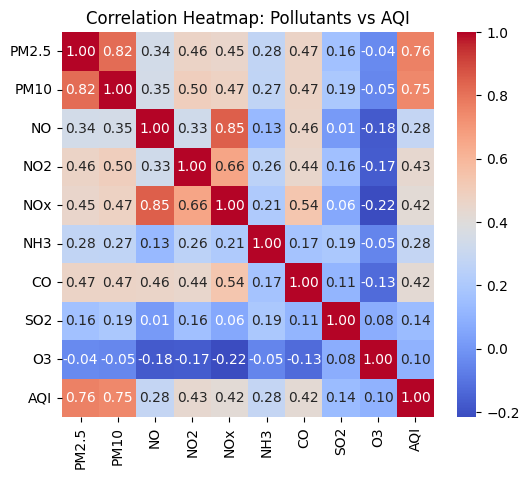

In [ ]:
import seaborn as sns

pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']
corr = merged_df[pollutants + ['AQI']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Pollutants vs AQI")
plt.show()



In [ ]:
from sklearn.model_selection import train_test_split

# Define features & target
drop_cols = ["StationId","Date","Time","datetime","StationName",
             "City","State","Status","AQI", "AQI_Bucket", "AQI_Category"]

X = df_features.drop(columns=drop_cols)
y = df_features["AQI"]

# Time-based split: 80% train, 20% test
train_size = int(0.8 * len(df_features))
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (174900, 84) (174900,)
Test shape: (43725, 84) (43725,)


In [ ]:
from sklearn.linear_model import LassoCV
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

lasso_fs = LassoCV(alphas=np.logspace(-4, 1, 50), cv=5, random_state=42, max_iter=5000)
lasso_fs.fit(X_train, y_train)

coef = pd.Series(lasso_fs.coef_, index=X_train.columns)

top_features = coef.abs().sort_values(ascending=False).head(20).index.tolist()
print("Top 20 features selected:", top_features)

Top 20 features selected: ['PM2.5', 'PM2.5mean48h', 'PM2.5mean24h', 'NOx', 'Benzenemean48h', 'PM10mean48h', 'NO', 'NH3', 'PM10', 'PM10mean24h', 'O3mean48h', 'NOmean48h', 'O3', 'SO2', 'O3mean24h', 'NO2mean24h', 'Toluene', 'PM2.5_lag96', 'Benzene', 'PM2.5_lag72']


# ***RANDOM FOREST***

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

rf_top = RandomForestRegressor(n_estimators=80, max_depth=20, random_state=42, n_jobs=-1)
rf_top.fit(X_train_top, y_train)

RandomForestRegressor(max_depth=20, n_estimators=80, n_jobs=-1, random_state=42)

In [ ]:
y_pred_top = rf_top.predict(X_test_top)
rmse_top = np.sqrt(mean_squared_error(y_test, y_pred_top))
r2_top = r2_score(y_test, y_pred_top)

print(f"RF with top features → RMSE: {rmse_top:.2f}, R²: {r2_top:.2f}")

RF with top features → RMSE: 34.00, R²: 0.64


In [ ]:
# Saving model
import joblib
joblib.dump(rf_top,"/content/drive/MyDrive/FSP PROJECT/rf_top.pkl")
print("Model saved as rf_top.pkl")

Model saved as rf_top.pkl


In [ ]:
import joblib

rf_top_loaded = joblib.load("/content/drive/MyDrive/FSP PROJECT/rf_top.pkl")


# ***LINEAR REGRESSION***

In [ ]:
from sklearn.linear_model import Lasso, Ridge, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
# Lasso (L1)
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.1, random_state=42))
])
lasso_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso', Lasso(alpha=0.1, random_state=42))])

In [ ]:
y_pred_lasso = lasso_pipeline.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso (L1) → RMSE: {rmse_lasso:.2f}, R²: {r2_lasso:.2f}")

Lasso (L1) → RMSE: 35.42, R²: 0.61


In [ ]:
# Ridge (L2)
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0, random_state=42))
])
ridge_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('ridge', Ridge(random_state=42))])

In [ ]:
y_pred_ridge = ridge_pipeline.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge (L2) → RMSE: {rmse_ridge:.2f}, R²: {r2_ridge:.2f}")

Ridge (L2) → RMSE: 35.54, R²: 0.61


In [ ]:
lasso_cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso_cv", LassoCV(alphas=np.logspace(-4, 1, 50), cv=5, random_state=42))
])
lasso_cv_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso_cv',
                 LassoCV(alphas=array([1.00000000e-04, 1.26485522e-04, 1.59985872e-04, 2.02358965e-04,
       2.55954792e-04, 3.23745754e-04, 4.09491506e-04, 5.17947468e-04,
       6.55128557e-04, 8.28642773e-04, 1.04811313e-03, 1.32571137e-03,
       1.67683294e-03, 2.12095089e-03, 2.68269580e-03, 3.39322177e-03,
       4.29193426e-03, 5.42867544e-03, 6....
       7.19685673e-02, 9.10298178e-02, 1.15139540e-01, 1.45634848e-01,
       1.84206997e-01, 2.32995181e-01, 2.94705170e-01, 3.72759372e-01,
       4.71486636e-01, 5.96362332e-01, 7.54312006e-01, 9.54095476e-01,
       1.20679264e+00, 1.52641797e+00, 1.93069773e+00, 2.44205309e+00,
       3.08884360e+00, 3.90693994e+00, 4.94171336e+00, 6.25055193e+00,
       7.90604321e+00, 1.00000000e+01]),
                         cv=5, random_state=42))])

In [ ]:
lasso_cv = lasso_cv_pipeline.named_steps["lasso_cv"]
y_pred_lasso_cv = lasso_cv_pipeline.predict(X_test)
rmse_lasso_cv = np.sqrt(mean_squared_error(y_test, y_pred_lasso_cv))
r2_lasso_cv = r2_score(y_test, y_pred_lasso_cv)

In [ ]:
print(f"Optimized Lasso → Best alpha: {lasso_cv.alpha_:.4f}")
print(f"RMSE: {rmse_lasso_cv:.2f}, R²: {r2_lasso_cv:.2f}")

Optimized Lasso → Best alpha: 0.0720
RMSE: 35.45, R²: 0.61


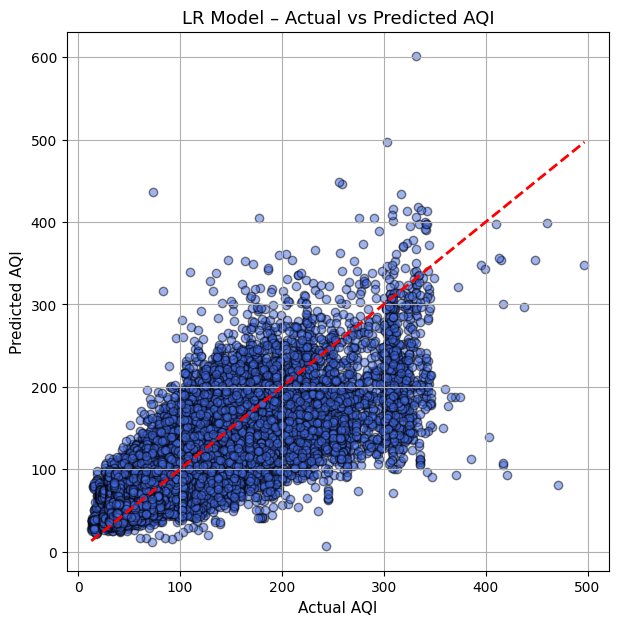

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_lasso_cv, alpha=0.5, color='royalblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.title("LR Model – Actual vs Predicted AQI", fontsize=13)
plt.xlabel("Actual AQI", fontsize=11)
plt.ylabel("Predicted AQI", fontsize=11)
plt.grid(True)
plt.show()


In [ ]:
joblib.dump(lasso_cv_pipeline, "/content/drive/MyDrive/FSP PROJECT/lasso_cv_pipeline.pkl")

['/content/drive/MyDrive/FSP PROJECT/lasso_cv_pipeline.pkl']

In [ ]:
lasso_cv_loaded = joblib.load("/content/drive/MyDrive/FSP PROJECT/lasso_cv_pipeline.pkl")

# ***GRU***

In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [ ]:
import numpy as np

def create_sequences(data, lookback=72, horizon=48):
    X, y = [], []
    for i in range(len(data) - lookback - horizon):
        X.append(data[i:i+lookback])           # past 72h
        y.append(data[i+lookback:i+lookback+horizon])  # next 48h
    return np.array(X), np.array(y)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
aqi_scaled = scaler.fit_transform(merged_df[["AQI"]].values)

lookback = 72
horizon = 48

X, y = create_sequences(aqi_scaled, lookback, horizon)

X = X.reshape(X.shape[0], lookback, 1)
y = y.reshape(y.shape[0], horizon)



In [ ]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

model = Sequential([
    GRU(64, return_sequences=False, input_shape=(lookback, 1)),
    Dense(horizon)   # directly outputs 48 future AQI values
])

model.compile(optimizer='adam', loss='mse')
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         3,120 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,984 (62.44 KB)

 Trainable params: 15,984 (62.44 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,         # stop after 5 epochs of no improvement
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,         # reduce LR after 3 epochs of no improvement
    verbose=1
)



In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)



Epoch 1/50
5473/5473 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step - loss: 0.0019 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 2/50
5473/5473 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - loss: 0.0015 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 3/50
5473/5473 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step - loss: 0.0015 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 4/50
5469/5473 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
5473/5473 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - loss: 0.0015 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 5/50
5473/5473 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - loss: 0.0014 - val_loss: 0.0013 - learning_rate: 5.0000e-04
Epoch 6/50
5473/5473 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - loss: 0.0014 - val_loss: 0.0013 - learning_rate: 5.0000e-04
Epoch 7/50
5473/5473 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - loss: 0.0014 - val_loss: 0.0013 - learning_rate: 5.0000e-04
Epoch 8/50
5470/5473 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0

In [ ]:
y_pred_scaled = model.predict(X_test)

# Inverse transform back to real AQI
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test)



1369/1369 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.metrics import r2_score

r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
print(f"GRU 48h Forecast RMSE: {rmse:.2f}, R²: {r2:.2f}")



GRU 48h Forecast RMSE: 35.93, R²: 0.75


In [ ]:
# Saving model
import joblib
model.save("/content/drive/MyDrive/FSP PROJECT/gru_model.keras")

In [ ]:
import tensorflow as tf

gru_loaded = tf.keras.models.load_model("/content/drive/MyDrive/FSP PROJECT/gru_model.keras")

In [ ]:
import numpy as np
import pandas as pd


last_sequence = aqi_scaled[-lookback:]
last_sequence = last_sequence.reshape(1, lookback, 1)


future_scaled = gru_loaded.predict(last_sequence)


future_aqi = scaler.inverse_transform(future_scaled)[0]


future_df = pd.DataFrame({
    "Hour Ahead": np.arange(1, horizon + 1),
    "Predicted AQI": future_aqi
})

print(future_df.head(48))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
    Hour Ahead  Predicted AQI
0            1     220.944153
1            2     219.715225
2            3     217.395523
3            4     215.225266
4            5     213.522064
5            6     213.904297
6            7     212.767075
7            8     211.107162
8            9     210.551193
9           10     208.649780
10          11     210.881241
11          12     209.327591
12          13     207.769104
13          14     207.432648
14          15     206.280899
15          16     207.323227
16          17     207.029953
17          18     205.398346
18          19     206.538315
19          20     206.816772
20          21     205.923141
21          22     205.328308
22          23     206.536804
23          24     207.136414
24          25     206.532272
25          26     205.480209
26          27     205.986267
27          28     205.274765
28          29     205.616745
29          30     206.190781
30          31     205.883865
3

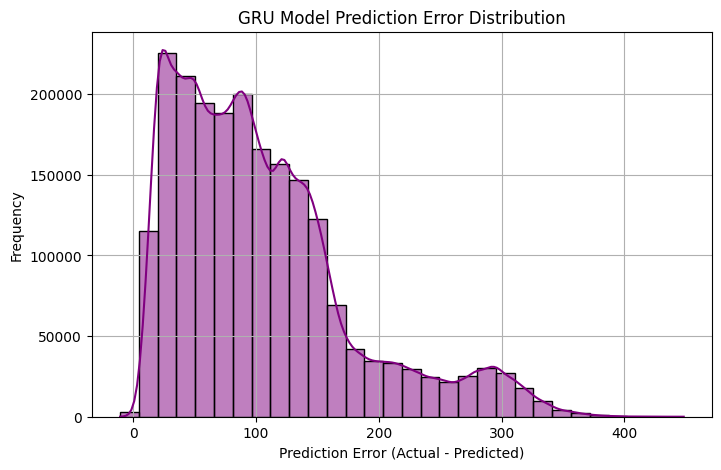

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

errors = y_true.flatten() - y_pred.flatten()

plt.figure(figsize=(8, 5))
sns.histplot(errors, bins=30, kde=True, color='purple')
plt.title("GRU Model Prediction Error Distribution")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [ ]:
def classify_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

# Apply the function to your predictions
future_df["AQI_Category"] = future_df["Predicted AQI"].apply(classify_aqi)

# Save again
future_df.to_csv("gru_48h_forecast.csv", index=False)
print(future_df.head(48))


    Hour Ahead  Predicted AQI AQI_Category
0            1     220.944153         Poor
1            2     219.715225         Poor
2            3     217.395523         Poor
3            4     215.225266         Poor
4            5     213.522064         Poor
5            6     213.904297         Poor
6            7     212.767075         Poor
7            8     211.107162         Poor
8            9     210.551193         Poor
9           10     208.649780         Poor
10          11     210.881241         Poor
11          12     209.327591         Poor
12          13     207.769104         Poor
13          14     207.432648         Poor
14          15     206.280899         Poor
15          16     207.323227         Poor
16          17     207.029953         Poor
17          18     205.398346         Poor
18          19     206.538315         Poor
19          20     206.816772         Poor
20          21     205.923141         Poor
21          22     205.328308         Poor
22         

In [ ]:
# Save predictions to CSV
future_df.to_csv("/content/drive/MyDrive/FSP PROJECT/gru_48h_forecast.csv", index=False)

print("✅ File saved as 'gru_48h_forecast.csv'")


✅ File saved as 'gru_48h_forecast.csv'


# ***SVM***

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
#Scaling

scaler_X = StandardScaler()
scaler_y = StandardScaler()

top_features = list(top_features)

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# scale input features
X_train_scaled = scaler_X.fit_transform(X_train_top)
X_test_scaled = scaler_X.transform(X_test_top)

# scale target
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

In [ ]:
split = 150000   # train size

X_train_small = X_train_scaled[:split]
y_train_small = y_train_scaled[:split]

X_test_small = X_test_scaled  # your already set test data
y_test_small = y_test_scaled


In [ ]:
svm = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
svm.fit(X_train_small, y_train_small)

SVR(C=10)

In [ ]:
y_pred_scaled = svm.predict(X_test_small)


In [ ]:
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"SVM (1-step) → RMSE: {rmse:.2f}, R²: {r2:.2f}")

SVM (1-step) → RMSE: 40.39, R²: 0.56


In [ ]:
import joblib

# Save the trained SVM model
joblib.dump(svm, "/content/drive/MyDrive/FSP PROJECT/svm_model.pkl")


joblib.dump(scaler_X, "/content/drive/MyDrive/FSP PROJECT/scaler_X.pkl")
joblib.dump(scaler_y, "/content/drive/MyDrive/FSP PROJECT/scaler_y.pkl")

print("✅ SVM model and scalers saved successfully!")


✅ SVM model and scalers saved successfully!


In [ ]:
svm_loaded = joblib.load("/content/drive/MyDrive/FSP PROJECT/svm_model.pkl")

In [ ]:
scaler_X = joblib.load("/content/drive/MyDrive/FSP PROJECT/scaler_X.pkl")
scaler_y = joblib.load("/content/drive/MyDrive/FSP PROJECT/scaler_y.pkl")


In [ ]:
print("Predicted AQI:", y_pred[1])


Predicted AQI: 273.3357154523054


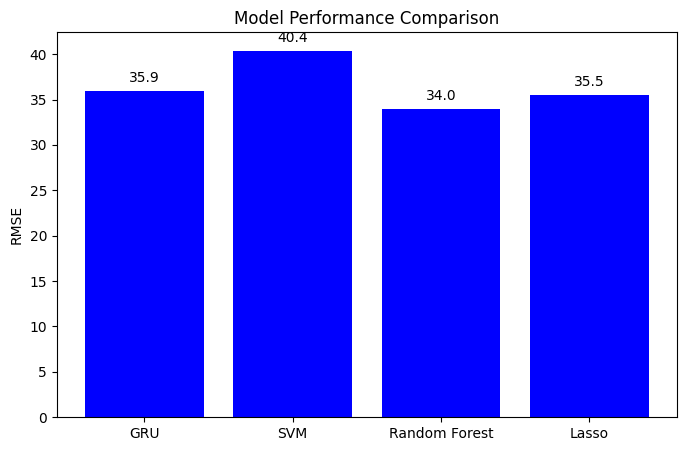

In [ ]:
import matplotlib.pyplot as plt

models = ['GRU', 'SVM', 'Random Forest', 'Lasso']
rmse = [35.93, 40.39, 34.00, 35.45]
r2 = [0.75, 0.56, 0.64, 0.61]

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.bar(models, rmse, color='blue')
ax1.set_ylabel("RMSE", color='black')
ax1.set_title("Model Performance Comparison")

for i, v in enumerate(rmse):
    ax1.text(i, v + 1, f"{v:.1f}", ha='center')

plt.show()


# **Next 48hrs prediction using GRU**



In [ ]:
forecast_df = pd.read_csv("/content/drive/MyDrive/FSP PROJECT/gru_48h_forecast.csv")
forecast_df

,Hour Ahead,Predicted AQI,AQI_Category
0,1,220.94415,Poor
1,2,219.71523,Poor
2,3,217.39552,Poor
3,4,215.22527,Poor
4,5,213.52206,Poor
5,6,213.90430,Poor
6,7,212.76707,Poor
7,8,211.10716,Poor
8,9,210.55120,Poor
9,10,208.64978,Poor
